### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [5]:
data = pd.read_csv('coupons.csv')

In [6]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [18]:


missing_counts = data.isnull().sum()
print(missing_counts[missing_counts >= 0])



destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64


3. Decide what to do about your missing data -- drop, replace, other...

In [19]:
#Going to Fill the data with Unknown as if we add data in future to see permutation and combination.
#to see how other data set change when the data is acquired for the campaign

data = data.fillna('Unknown')


print("Missing values after replacement:")
print(data.isnull().sum())

Missing values after replacement:
destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
car                     0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64


4. What proportion of the total observations chose to accept the coupon?



In [21]:
#find the acceptance proportion
acceptance_proportion = data['Y'].mean()

#print data with acceptance percentage
print(f"Proportion of accepted coupons: {acceptance_proportion:.2%}")


Proportion of accepted coupons: 56.84%


5. Use a bar plot to visualize the `coupon` column.

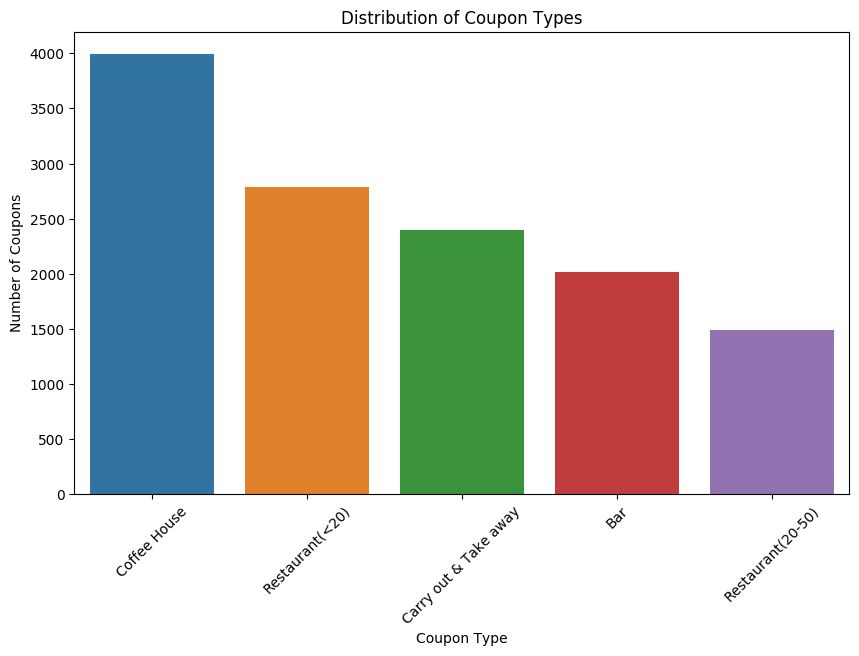

In [22]:
# Create a bar plot for the 'coupon' column using Seaborn
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='coupon', order=data['coupon'].value_counts().index)

# Add titles and labels for clarity
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Number of Coupons')

# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45)

# Display the plot
plt.show()

6. Use a histogram to visualize the temperature column.

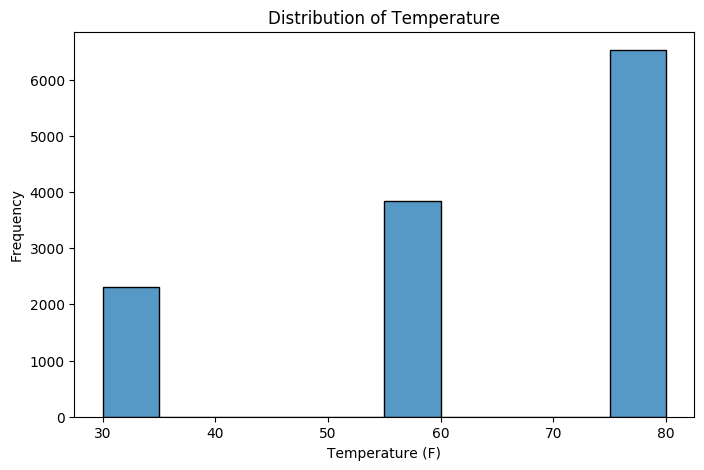

In [23]:
# Create a histogram for the 'temperature' column
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='temperature', bins=10, kde=False)

# Add titles and labels for clarity
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (F)')
plt.ylabel('Frequency')

# Display the plot
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [25]:
bar_coupons = data[data['coupon'] == 'Bar']

# Display the first few rows to verify it worked
display(bar_coupons.head())



,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [26]:
bar_acceptance_rate = bar_coupons['Y'].mean()

# Print the result formatted as a percentage
print(f"Proportion of bar coupons accepted: {bar_acceptance_rate:.2%}")

Proportion of bar coupons accepted: 41.00%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [27]:
print(f"Unique values in 'Bar' column: {bar_coupons['Bar'].unique()}\n")

# 1. Define the categories for 3 or fewer times, and more than 3 times
three_or_fewer = ['never', 'less1', '1~3']
more_than_three = ['4~8', 'gt8']

# 2. Filter the bar_coupons dataframe into two separate groups
group_3_or_fewer = bar_coupons[bar_coupons['Bar'].isin(three_or_fewer)]
group_more_than_3 = bar_coupons[bar_coupons['Bar'].isin(more_than_three)]

# 3. Calculate the acceptance rate (mean of 'Y') for both groups
rate_3_or_fewer = group_3_or_fewer['Y'].mean()
rate_more_than_3 = group_more_than_3['Y'].mean()

# 4. Print the comparison
print(f"Acceptance rate (3 or fewer times a month): {rate_3_or_fewer:.2%}")
print(f"Acceptance rate (More than 3 times a month): {rate_more_than_3:.2%}")

Unique values in 'Bar' column: ['never' 'less1' '1~3' 'gt8' 'Unknown' '4~8']

Acceptance rate (3 or fewer times a month): 37.06%
Acceptance rate (More than 3 times a month): 76.88%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [28]:
# Optional: Check unique values in 'age' to see exactly how they are formatted
print(f"Unique values in 'age' column: {bar_coupons['age'].unique()}\n")

# 1. Define the specific categories that meet the criteria
# '1~3', '4~8', and 'gt8' represent going to a bar more than once a month
bars_more_than_once = ['1~3', '4~8', 'gt8']

# These are the typical string categories for ages over 25 in this dataset
age_over_25 = ['26', '31', '36', '41', '46', '50plus'] 

# 2. Create a "mask" (a True/False filter) for the specific group
# We use the ampersand (&) to ensure BOTH conditions are met
target_group_mask = (bar_coupons['Bar'].isin(bars_more_than_once)) & (bar_coupons['age'].isin(age_over_25))

# 3. Filter the dataframe into our two comparison groups
target_group = bar_coupons[target_group_mask]

# The tilde (~) means "NOT", so this captures everyone who doesn't fit the target group mask
all_others_group = bar_coupons[~target_group_mask]

# 4. Calculate the acceptance rates (mean of 'Y')
rate_target = target_group['Y'].mean()
rate_others = all_others_group['Y'].mean()

# 5. Print the final comparison
print(f"Acceptance rate (Bar > 1/month AND Age > 25): {rate_target:.2%}")
print(f"Acceptance rate (All others): {rate_others:.2%}")

Unique values in 'age' column: ['21' '46' '26' '31' '41' '50plus' '36' 'below21']

Acceptance rate (Bar > 1/month AND Age > 25): 69.52%
Acceptance rate (All others): 33.50%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [29]:
# Optional: Print unique values just to double-check the exact text formatting in your dataset
print("Unique passengers:", bar_coupons['passanger'].unique())
print("Unique occupations (first 5):", bar_coupons['occupation'].unique()[:5], "\n")

# 1. Define the list for going to the bar more than once a month
bars_more_than_once = ['1~3', '4~8', 'gt8']

# 2. Create the mask combining all three conditions
# Condition 1: Bar visits > 1
# Condition 2: Passenger is NOT 'Kid(s)'
# Condition 3: Occupation is NOT 'Farming Fishing & Forestry'
target_mask = (
    (bar_coupons['Bar'].isin(bars_more_than_once)) & 
    (bar_coupons['passanger'] != 'Kid(s)') & 
    (bar_coupons['occupation'] != 'Farming Fishing & Forestry')
)

# 3. Filter into two groups
target_group = bar_coupons[target_mask]
all_others_group = bar_coupons[~target_mask]

# 4. Calculate the acceptance rates
rate_target = target_group['Y'].mean()
rate_others = all_others_group['Y'].mean()

# 5. Print the comparison
print(f"Acceptance rate (Bar > 1/month, No kids, Not farming/fishing/forestry): {rate_target:.2%}")
print(f"Acceptance rate (All others): {rate_others:.2%}")

Unique passengers: ['Kid(s)' 'Alone' 'Friend(s)' 'Partner']
Unique occupations (first 5): ['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'] 

Acceptance rate (Bar > 1/month, No kids, Not farming/fishing/forestry): 71.32%
Acceptance rate (All others): 29.60%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [30]:
# 1. Define the specific text categories based on the dataset
bars_more_than_once = ['1~3', '4~8', 'gt8']
age_under_30 = ['below21', '21', '26']
cheap_rest_more_than_4 = ['4~8', 'gt8']
income_less_than_50k = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

# 2. Build Condition 1: Bar > 1/month, No kids, Not widowed
cond1 = (
    (bar_coupons['Bar'].isin(bars_more_than_once)) & 
    (bar_coupons['passanger'] != 'Kid(s)') & 
    (bar_coupons['maritalStatus'] != 'Widowed')
)

# 3. Build Condition 2: Bar > 1/month, Under 30
cond2 = (
    (bar_coupons['Bar'].isin(bars_more_than_once)) & 
    (bar_coupons['age'].isin(age_under_30))
)

# 4. Build Condition 3: Cheap restaurants > 4/month, Income < 50K
cond3 = (
    (bar_coupons['RestaurantLessThan20'].isin(cheap_rest_more_than_4)) & 
    (bar_coupons['income'].isin(income_less_than_50k))
)

# 5. Combine all three conditions using the OR operator (|)
target_mask = cond1 | cond2 | cond3

# 6. Filter into our two groups
target_group = bar_coupons[target_mask]
all_others_group = bar_coupons[~target_mask]

# 7. Calculate and print the acceptance rates
rate_target = target_group['Y'].mean()
rate_others = all_others_group['Y'].mean()

print(f"Acceptance rate (Target Group): {rate_target:.2%}")
print(f"Acceptance rate (All others): {rate_others:.2%}")

Acceptance rate (Target Group): 58.89%
Acceptance rate (All others): 29.81%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  